


Found 19840 images belonging to 10 classes.
Found 4960 images belonging to 10 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 gaussian_noise (GaussianNo  (None, 64, 64, 3)         0         
 ise)                                                            
                                                                 
 block1_conv1 (Conv2D)       (None, 64, 64, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 64, 64, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 32, 32, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 3

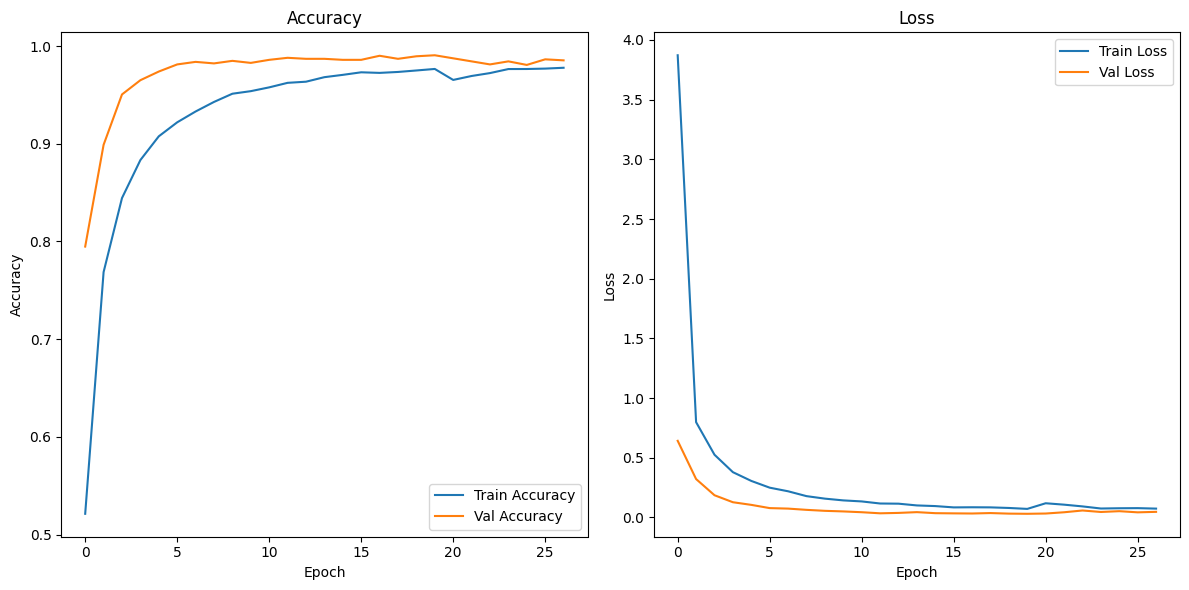

78/78 [==============================] - 224s 3s/step
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       496
           1       0.98      1.00      0.99       496
           2       0.98      0.99      0.98       496
           3       1.00      0.97      0.98       496
           4       1.00      1.00      1.00       496
           5       1.00      1.00      1.00       496
           6       1.00      0.99      0.99       496
           7       1.00      1.00      1.00       496
           8       1.00      1.00      1.00       496
           9       1.00      1.00      1.00       496

    accuracy                           0.99      4960
   macro avg       0.99      0.99      0.99      4960
weighted avg       0.99      0.99      0.99      4960

Accuracy:  0.9940
Precision: 0.9940
Recall:    0.9940
F1 Score:  0.9939


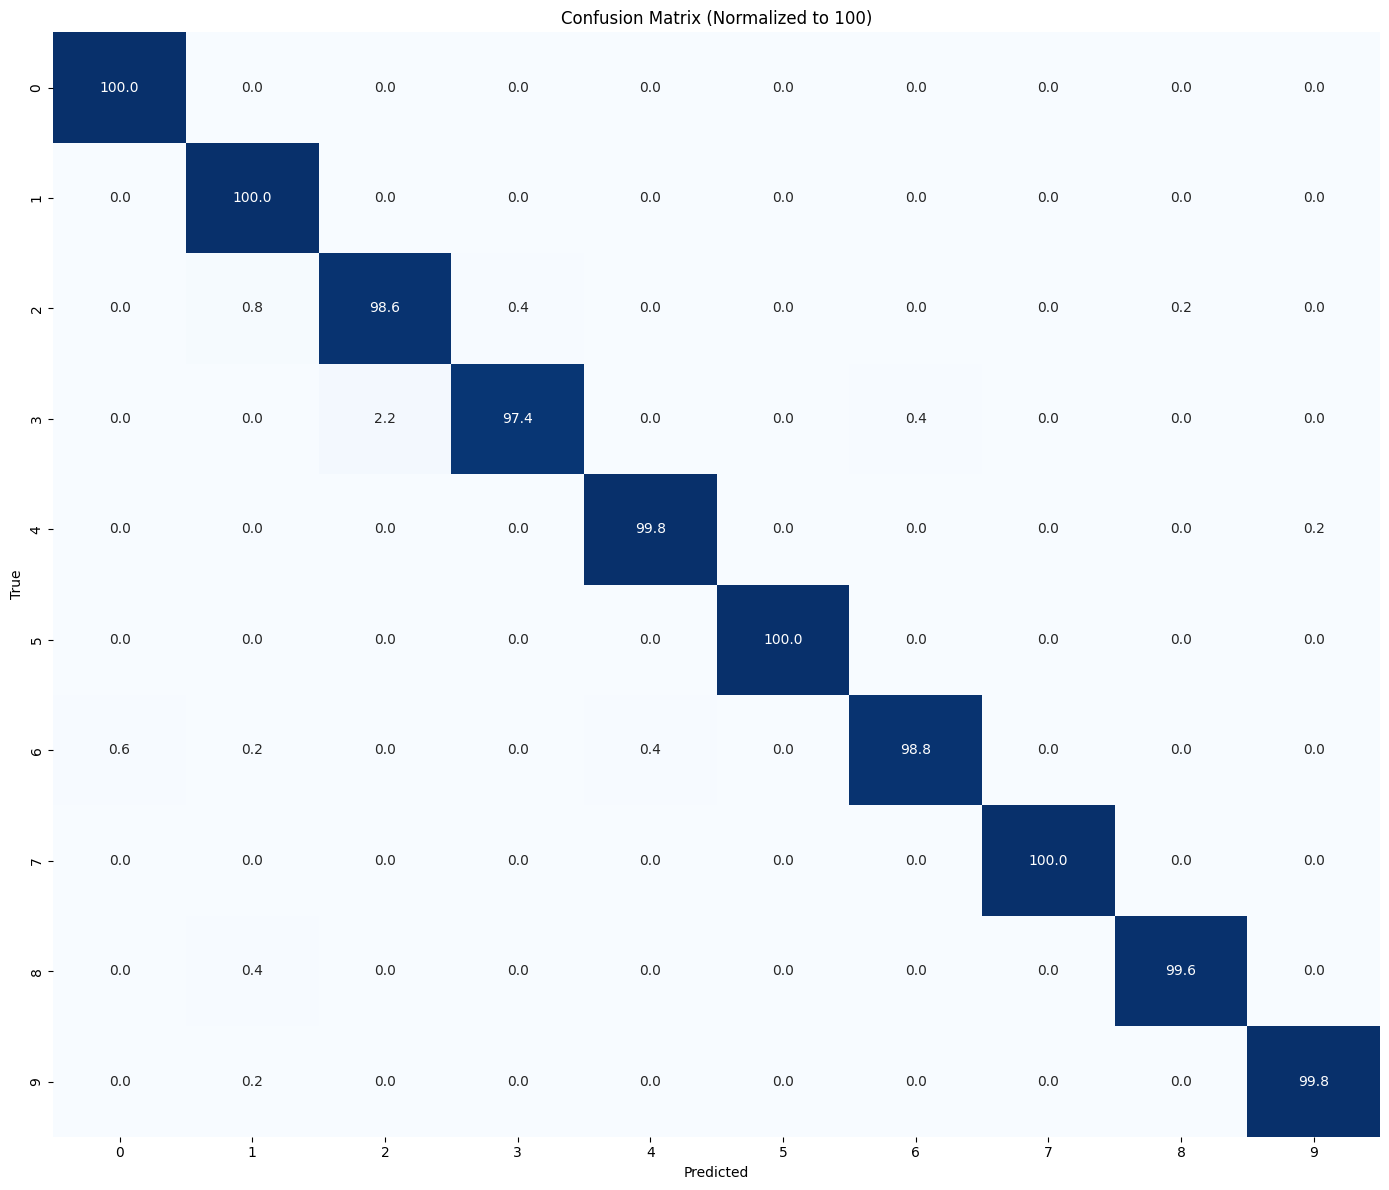

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import tensorflow as tf
import random

# For reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# -------- Input layer with Gaussian noise --------
input_layer = layers.Input(shape=(64, 64, 3))
noise = layers.GaussianNoise(0.25)(input_layer)

# -------- Load VGG16 base model using noisy input --------
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=noise)
base_model.trainable = False

# -------- Add classification head --------
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model = Model(inputs=input_layer, outputs=outputs)

# -------- Data Generators with strong augmentation --------
train_dir = r'E:\cnndatasets\numbers_dataset\train'
val_dir = r'E:\cnndatasets\numbers_dataset\val'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.20,
    height_shift_range=0.20,
    zoom_range=0.20,
    shear_range=0.25,
    brightness_range=[0.4, 1.6],
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    seed=42
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# -------- Learning rate schedule --------
def lr_schedule(epoch):
    if epoch < 20:
        return 0.0001
    else:
        return 0.0005

lr_callback = callbacks.LearningRateScheduler(lr_schedule, verbose=1)

# -------- Callbacks --------
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

# -------- Compile model --------
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
plot_model(model, to_file='vgg16_fast_model_structure.png', show_shapes=True, show_layer_names=True)

# -------- Train model --------
max_train_steps = 310
max_val_steps = 30

history = model.fit(
    train_generator,
    epochs=40,
    steps_per_epoch=min(max_train_steps, train_generator.samples // train_generator.batch_size),
    validation_data=val_generator,
    validation_steps=min(max_val_steps, val_generator.samples // val_generator.batch_size),
    callbacks=[early_stop, lr_callback, reduce_lr],
    verbose=1
)

# -------- Save model --------
model.save('numeral_vgg16_fast_model.keras')

# -------- Plot training history --------
epochs_ran = len(history.history['accuracy'])
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs_ran), history.history['accuracy'], label='Train Accuracy')
plt.plot(range(epochs_ran), history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs_ran), history.history['loss'], label='Train Loss')
plt.plot(range(epochs_ran), history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('vgg16_fast_training_plot.png')
plt.show()

# -------- Evaluation on full validation set --------
val_generator.reset()
steps = int(np.ceil(val_generator.samples / val_generator.batch_size))
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator, steps=steps)
y_pred = np.argmax(y_pred_probs, axis=-1)
class_labels = list(val_generator.class_indices.keys())

# Generate classification report text
report = classification_report(y_true, y_pred, target_names=class_labels, zero_division=0)
print("Classification Report:\n", report)

# Save classification report as image
def save_classification_report_as_image(report_text, filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    ax.text(0, 1, report_text, fontsize=12, fontfamily='monospace', verticalalignment='top')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.close()

save_classification_report_as_image(report, 'classification_report.png')

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

# -------- Confusion Matrix --------
cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1)
row_sums[row_sums == 0] = 1  # avoid division by zero
cm_normalized = cm.astype('float') / row_sums[:, np.newaxis] * 100

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=False
)
plt.title("Confusion Matrix (Normalized to 100)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig('vgg16_fast_confusion_matrix.png')
plt.show()
